### Derive cohesion and friction angle from the Direct Shear Test
In this notebook, we will derive the cohesion and friction angle by using least square method, in this case it actually is Linear Regression method that given from sklearn package. 

the equation that we will use is:
$$\tau = c + \sigma \tan(\phi)$$

where:
- $\tau$ is the shear stress
- $c$ is the cohesion
- $\sigma$ is the normal stress
- $\phi$ is the friction angle

All the source code have refactored in utils.py file for better readability 

In [2]:
from utils import C_PhiCalulator, read_csv_files

## Demo for a layer

Cohesion (c): 0.083
Friction angle (φ): 25.487 



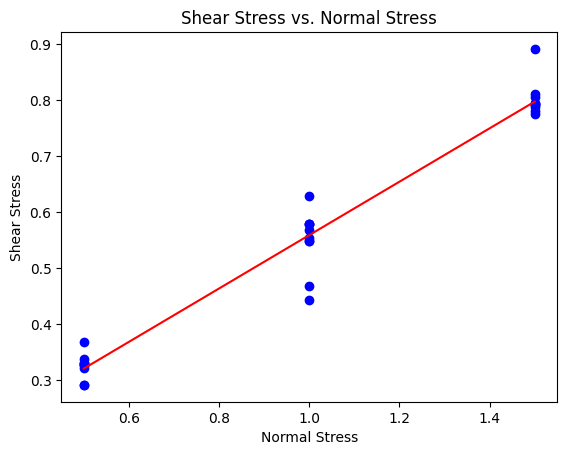

(0.0828666666666667, 0.4448344697056924)

In [6]:
C_PhiCalulator('LayerDST/Layer4.csv', message=True, plot=True)

In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv('./C_Phi/Layer10.csv')

print(data.mean())

Phi         25.285417
Cohesion     0.086525
dtype: float64


## Update data on google sheet

In [15]:
import gspread as gs
import numpy as np

gc = gs.service_account(filename='pysheetAuth.json')  

sheet = gc.open('Pysheet').worksheet('C_Phi')

folder_path = "./LayerDST"
dataframes = read_csv_files(folder_path)

if dataframes:
    sheet.clear()
    sheet.append_row(['Layer', 'C', 'ɸ (degree ⁰)'])
    for filename, df in dataframes.items():
        print(f"C_phi calcualted for {filename}")
        C, Phi = C_PhiCalulator(f'{folder_path}/{filename}')
        filename = filename.replace('.csv', '').replace('Layer', '')
        sheet.append_row([filename, np.round(C, 3), np.round(np.degrees(Phi), 3)])

C_phi calcualted for Layer1.csv
C_phi calcualted for Layer2.csv
C_phi calcualted for Layer3.csv
C_phi calcualted for Layer4.csv
C_phi calcualted for Layer5.csv
C_phi calcualted for Layer6.csv
